
- 데이터: [KB부동산 데이터 허브](https://data.kbland.kr/) → KB 통계 → 주택가격동향조사
    - [주간 아파트 매매가격지수](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=weekAptSalePriceInx) 전체('24년 10월 7일 기준)
    - [주간 아파트 전세가격지수](https://data.kbland.kr/kbstats/wmh?tIdx=HT01&tsIdx=weekAptRentPriceInx) 전체('24년 10월 7일 기준)

- 가격지수: 기준시점(22년 1월 10일) 대비 조사 시점(24년 10월)의 가격 비율 (주택별·지역별 가중)

# 데이터의 목표: 주택 매매가와 전세가격의 데이터를 확인해서 전세를 낀 매매를 통해 시세 차익을 도모한다.
## 세부목표 1: 주택 매매가 크게 상승하는 지역을 찾는다.
## 세부목표 2: 그 중 전세가격이 안정적으로 유지되거나 하락하는 지역을 찾는다.
## 세부목표 3: 해당 지역을 매매할 경우 몇 %의 수익률을 얻을 수 있을지 예측한다.

# 환경설정

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

In [1]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
Sudo가 이 컴퓨터에서 사용하지 않도록 설정되어 있습니다. 사용하도록 설정하려면 으로 이동하세요. ]8;;ms-settings:developers\Developer Settings page]8;;\ 설정 앱의
'rm'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


# 데이터 불러오기
두 개의 엑셀파일을 읽어와서 각각 `df_sale`, `df_rent` 변수에 할당하고, shape을 확인

In [2]:
import pandas as pd

df_sale = pd.read_excel("./data/주간 아파트 매매가격지수_20260210.xlsx")
df_rent = pd.read_excel("./data/주간 아파트 전세가격지수_20260210.xlsx")

In [3]:
df_sale.shape, df_rent.shape

((282, 899), (282, 899))

In [4]:
df_sale.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Columns: 899 entries, 지역명 to 2026-02-02 00:00:52
dtypes: float64(1), object(898)
memory usage: 1.9+ MB


In [5]:
df_sale.columns

Index([              '지역명', 2008-04-07 00:00:52, 2008-04-14 00:00:52,
       2008-04-21 00:00:52, 2008-04-28 00:00:52, 2008-05-05 00:00:52,
       2008-05-12 00:00:52, 2008-05-19 00:00:52, 2008-05-26 00:00:52,
       2008-06-02 00:00:52,
       ...
       2025-12-01 00:00:52, 2025-12-08 00:00:52, 2025-12-15 00:00:52,
       2025-12-22 00:00:52, 2025-12-29 00:00:52, 2026-01-05 00:00:52,
       2026-01-12 00:00:52, 2026-01-19 00:00:52, 2026-01-26 00:00:52,
       2026-02-02 00:00:52],
      dtype='object', length=899)

In [6]:
df_sale['지역명'].unique()

array(['전국', '서울', '강북14개구', '종로구', '중구', '용산구', '성동구', '광진구', '동대문구',
       '중랑구', '성북구', '강북구', '도봉구', '노원구', '은평구', '서대문구', '마포구', '강남11개구',
       '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구', '관악구', '서초구', '강남구',
       '송파구', '강동구', '수도권', '6개광역시', '5개광역시', '기타지방', '부산', '서구', '동구',
       '영도구', '부산진구', '동래구', '남구', '북구', '해운대구', '사하구', '금정구', '연제구',
       '수영구', '사상구', '기장군', '대구', '수성구', '달서구', '달성군', '인천', '미추홀구',
       '연수구', '남동구', '부평구', '계양구', '강화군', '광주', '광산구', '대전', '유성구', '대덕구',
       '울산', '울주군', '세종', '경기', '수원시', '수원시 장안구', '수원시 권선구', '수원시 팔달구',
       '수원시 영통구', '성남시', '성남시 수정구', '성남시 중원구', '성남시 분당구', '의정부시', '안양시',
       '안양시 만안구', '안양시 동안구', '부천시', '부천시 원미구', '부천시 소사구', '부천시 오정구',
       '광명시', '평택시', '동두천시', '안산시', '안산시 상록구', '안산시 단원구', '고양시',
       '고양시 덕양구', '고양시 일산동구', '고양시 일산서구', '과천시', '구리시', '남양주시', '오산시',
       '시흥시', '군포시', '의왕시', '하남시', '용인시', '용인시 처인구', '용인시 기흥구', '용인시 수지구',
       '파주시', '이천시', '안성시', '김포시', '화성시', '화성시 만세구', '화성시 효행구', '화성시 병점구'

In [7]:
df_sale.head(5)

,지역명,2008-04-07 00:00:52,2008-04-14 00:00:52,2008-04-21 00:00:52,2008-04-28 00:00:52,2008-05-05 00:00:52,2008-05-12 00:00:52,2008-05-19 00:00:52,2008-05-26 00:00:52,2008-06-02 00:00:52,...,2025-12-01 00:00:52,2025-12-08 00:00:52,2025-12-15 00:00:52,2025-12-22 00:00:52,2025-12-29 00:00:52,2026-01-05 00:00:52,2026-01-12 00:00:52,2026-01-19 00:00:52,2026-01-26 00:00:52,2026-02-02 00:00:52
0,전국,58.012546,58.088746,58.197535,58.281398,58.355038,58.427476,58.493162,58.553072,58.616457,...,90.563892,90.61607,90.669762,90.723634,90.780566,90.832983,90.896435,90.988497,91.076983,91.171226
1,서울,59.733068,59.88161,60.042211,60.163088,60.278446,60.387011,60.458109,60.525847,60.595353,...,103.430333,103.627722,103.80823,104.024977,104.25149,104.460231,104.710833,105.106874,105.440872,105.776555
2,강북14개구,59.738949,59.980174,60.250467,60.443754,60.625386,60.795838,60.908856,61.036939,61.155861,...,96.360463,96.505732,96.644737,96.808277,96.960962,97.152036,97.360009,97.724559,98.011018,98.310304
3,종로구,68.904068,69.003505,69.014767,69.06011,69.06011,69.019522,69.019522,69.060926,69.101609,...,105.373269,105.429936,105.540645,105.61693,105.694778,105.725094,105.817512,105.971637,106.03029,106.657303
4,중구,66.375784,66.420175,66.554633,66.66407,66.709373,66.709373,66.709373,66.709373,66.709373,...,108.51246,108.910689,109.1411,109.150096,109.274603,109.580119,109.884284,110.521498,110.709423,110.878716


In [8]:
df_sale_long = df_sale.melt(
    id_vars='지역명',
    var_name='날짜',
    value_name='매매지수'
)
df_sale_long['날짜'] = pd.to_datetime(df_sale_long['날짜'])
df_sale_long['연도'] = df_sale_long['날짜'].dt.year


df_sale_long


,지역명,날짜,매매지수,연도
0,전국,2008-04-07 00:00:52,58.012546,2008
1,서울,2008-04-07 00:00:52,59.733068,2008
2,강북14개구,2008-04-07 00:00:52,59.738949,2008
3,종로구,2008-04-07 00:00:52,68.904068,2008
4,중구,2008-04-07 00:00:52,66.375784,2008
...,...,...,...,...
253231,무주군,2026-02-02 00:00:52,110.667528,2026
253232,임실군,2026-02-02 00:00:52,109.431223,2026
253233,순창군,2026-02-02 00:00:52,103.264275,2026
253234,고창군,2026-02-02 00:00:52,119.761,2026


In [9]:
df_sale_long.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253236 entries, 0 to 253235
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   지역명     253236 non-null  object        
 1   날짜      253236 non-null  datetime64[ns]
 2   매매지수    253236 non-null  object        
 3   연도      253236 non-null  int32         
dtypes: datetime64[ns](1), int32(1), object(2)
memory usage: 6.8+ MB


In [10]:
df_sale_long['매매지수'] = (
    df_sale_long['매매지수']
    .astype(str)
    .str.replace(',', '')
    .str.strip()
)

In [11]:
(df_sale_long['매매지수'] == '-').sum()

76913

In [12]:
(df_sale_long['매매지수'] == '-').mean()

0.303720640035382

In [13]:
missing_ratio = (
    (df_sale_long['매매지수'] == '-')
    .groupby(df_sale_long['지역명'])
    .mean()
    .sort_values(ascending=False)
)

missing_ratio.head(10)

지역명
화성시 효행구    0.998886
화성시 병점구    0.998886
화성시 만세구    0.998886
화성시 동탄구    0.998886
구례군        0.887528
순창군        0.887528
부천시 소사구    0.881960
부천시 원미구    0.881960
부천시 오정구    0.881960
횡성군        0.818486
Name: 매매지수, dtype: float64

###데이터에서 -로 되어 있는 값이 많아. 최근 10년의 데이터만 활용하기로 정함.(집계가 안된 값이 너무 많음)

In [14]:
df_sale_long = df_sale.melt(id_vars='지역명',
                            var_name='날짜',
                            value_name='매매지수')

df_rent_long = df_rent.melt(id_vars='지역명',
                            var_name='날짜',
                            value_name='전세지수')

In [15]:
df_sale_long['날짜'] = pd.to_datetime(df_sale_long['날짜'])
df_rent_long['날짜'] = pd.to_datetime(df_rent_long['날짜'])

In [16]:
df_sale_long = df_sale_long[df_sale_long['날짜'].dt.year >= 2016]
df_rent_long = df_rent_long[df_rent_long['날짜'].dt.year >= 2016]

In [19]:
# 매매 기준
sale_dash_count = (df_sale_long['매매지수'] == '-').sum()
sale_dash_ratio = (df_sale_long['매매지수'] == '-').mean()

# 전세 기준
rent_dash_count = (df_rent_long['전세지수'] == '-').sum()
rent_dash_ratio = (df_rent_long['전세지수'] == '-').mean()

sale_dash_count, sale_dash_ratio, rent_dash_count, rent_dash_ratio

(34366, 0.24084041151571217, 34366, 0.24084041151571217)

In [20]:
df_sale_long['날짜'] = pd.to_datetime(df_sale_long['날짜'])

recent_sale = df_sale_long[df_sale_long['날짜'] >= '2016-01-01']

In [21]:
(recent_sale['매매지수'] == '-').mean()

0.24084041151571217

In [23]:
recent_sale['is_dash'] = (recent_sale['매매지수'] == '-')

dash_by_region = (
    recent_sale
    .groupby('지역명')['is_dash']
    .mean()
    .sort_values(ascending=False)
)

dash_by_region.head(30)

지역명
화성시 효행구    0.998024
화성시 병점구    0.998024
화성시 만세구    0.998024
화성시 동탄구    0.998024
구례군        0.800395
순창군        0.800395
부천시 오정구    0.790514
부천시 원미구    0.790514
부천시 소사구    0.790514
정읍시        0.677866
부안군        0.677866
부여군        0.677866
횡성군        0.677866
정선군        0.677866
보은군        0.677866
사천시        0.677866
산청군        0.677866
봉화군        0.677866
밀양시        0.677866
보성군        0.677866
보령시        0.677866
상주시        0.677866
제주시        0.677866
문경시        0.677866
무주군        0.677866
무안군        0.677866
동해시        0.677866
영광군        0.677866
증평군        0.677866
진도군        0.677866
Name: is_dash, dtype: float64

### 행정구조 개편 + 세분화 지역 신설 문제
### 화성시는 있음 그런데 화성시 만세구 / 효행구 / 병점구 / 동탄구는 거의 99%가 '-'
### 신설·세분화된 지역은 과거 데이터가 원래 없다. 그래서 80~99% '-'가 나옴.
### 1단계: 분석 대상 정리
### 🔥 추천 전략

### 1️⃣ 광역시·도 단위는 제외
### → 전국, 수도권, 6개광역시 등은 제거

### 2️⃣ 신설 세부구는 제거
### → dash 비율 50% 이상 지역 제거

### 3️⃣ 최소 데이터 보유율 기준 설정
### → 예: 최근 10년 중 80% 이상 존재

In [24]:
# 50% 이상 '-' 지역 제거

valid_regions = dash_by_region[dash_by_region < 0.5].index

recent_sale_clean = recent_sale[
    recent_sale['지역명'].isin(valid_regions)
].copy()

In [25]:
# '-' → NaN → float 변환

import numpy as np

recent_sale_clean['매매지수'] = (
    recent_sale_clean['매매지수']
    .replace('-', np.nan)
    .astype(float)
)

C:\Users\Admin\AppData\Local\Temp\ipykernel_11196\2009017698.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace('-', np.nan)


In [26]:
recent_sale_clean = recent_sale_clean.dropna(subset=['매매지수'])
recent_sale_clean['지역명'].nunique()

164

In [27]:
# 주간 수익률
recent_sale_clean = recent_sale_clean.sort_values(['지역명','날짜'])

recent_sale_clean['주간수익률'] = (
    recent_sale_clean
    .groupby('지역명')['매매지수']
    .pct_change()
)

In [28]:
# 가격 변동성
volatility = (
    recent_sale_clean
    .groupby('지역명')['주간수익률']
    .std()
    .sort_values(ascending=False)
)

volatility.head(10)

지역명
서구     0.183191
강서구    0.164430
중구     0.151668
동구     0.108021
남구     0.065104
북구     0.055319
세종     0.003617
오산시    0.003389
연수구    0.003272
광명시    0.003260
Name: 주간수익률, dtype: float64

In [29]:
# 10년 누적 수익률
return_10y = (
    recent_sale_clean
    .groupby('지역명')['매매지수']
    .apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)
    .sort_values(ascending=False)
)

return_10y.head(10)

지역명
성남시 분당구    1.221572
송파구        1.210351
강남구        1.125973
마포구        1.093169
양천구        1.051105
영등포구       1.035312
용산구        1.024985
성남시        1.024417
성동구        1.017357
광진구        0.991732
Name: 매매지수, dtype: float64

In [31]:
#가격 변동성과 10년 수익률
analysis = pd.concat([volatility, return_10y], axis=1)
analysis.columns = ['변동성','10년수익률']

analysis.sort_values('변동성', ascending=False).head(10)

,변동성,10년수익률
지역명,,
서구,0.183191,-0.065749
강서구,0.164430,0.374150
중구,0.151668,0.417057
동구,0.108021,-0.061916
남구,0.065104,0.291531
북구,0.055319,0.116233
세종,0.003617,0.344038
오산시,0.003389,0.168759
연수구,0.003272,0.357363


In [ ]:
#가격 변동성과 10년 수익률(내림차순)
analysis.sort_values('10년수익률', ascending=False).head(10)

,변동성,10년수익률
지역명,,
성남시 분당구,0.002822,1.221572
송파구,0.002580,1.210351
강남구,0.002225,1.125973
마포구,0.002280,1.093169
양천구,0.002327,1.051105
영등포구,0.002031,1.035312
용산구,0.001936,1.024985
성남시,0.002576,1.024417
성동구,0.002696,1.017357


In [33]:
# 전세 수익률 & 변동성 계산
sale_rent = sale.merge(rent, on=['지역명','날짜'])
sale_rent['전세가율'] = sale_rent['전세지수'] / sale_rent['매매지수']

NameError: name 'sale' is not defined

In [12]:
df_sale_long['매매지수'] = (
    df_sale_long['매매지수']
    .replace('-', None)
)

df_sale_long['매매지수'] = pd.to_numeric(df_sale_long['매매지수'])

df_sale_long['매매지수'] = (
    df_sale_long
    .sort_values(['지역명','날짜'])
    .groupby('지역명')['매매지수']
    .ffill()
)

In [13]:
df_sale_long['매매지수'] = pd.to_numeric(df_sale_long['매매지수'])

In [ ]:
# 코드를 작성하시오


## 데이터 구조 변경
 - 컬럼은 지역명, 인덱스는 시간 정보
 - 서울 지역만 필터링
 - 집계 데이터(예. 전국, 서울, 강북14개구 등)는 제외
 - 구조 변경 결과 shape: (831, 25)
 - 변경된 데이터는 신규 변수 `df_sale_seoul`와 `df_rent_seoul`에 할당

 (예시)


 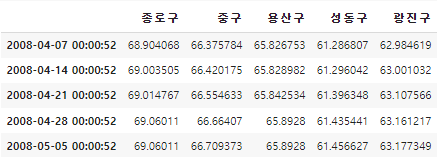

In [ ]:
# 코드를 작성하시오


## Long Form으로 변경
- `지역명`이 값으로 할당되도록 데이터 구조 변경
- 최종 구조 변경된 컬럼은 `지역명`, `매매가격지수`의 컬럼을 가지고 있음(전세 데이터는 `지역명`, `전세가격지수`의 컬럼을 가지고 있음)
- 변경한 데이터는 각각 `df_sale_seoul_long`, `df_rent_seoul_long` 에 할당
- 변경된 데이터의 shape: (20775, 2)

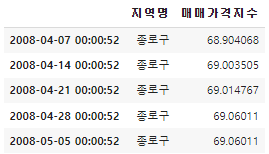

In [ ]:
# 코드를 작성하시오


# 데이터 시각화
- 전처리가 수행된 데이터 프레임  `df_sale_seoul`와 `df_rent_seoul` 또는 `df_sale_seoul_long`, `df_rent_seoul_long`을 사용하여 데이터 시각화 수행
- (예시)
    - `강남구`의 날짜별 `매매가격지수`, `전세가격지수` 시각화
    - `강남구`의 `매매가격지수`, `전세가격지수` 상관관계 시각화
    - `매매가격지수`와 `전세가격지수`의 차이가 가장 큰(적은) 지역을 판단하고, 해당 지역에 가격지수를 시각화
    - 연도별 데이터 집계하여 시각화 등
    
- 필요 시 추가 데이터 전처리 수행    

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트(나눔고딕)을 기본 폰트로 사용하도록 설정
plt.rcParams["font.family"] = 'NanumGothic'

# 그래프에서 마이너스 폰트 깨지는 문제 해결
mpl.rcParams['axes.unicode_minus'] = False

### 강남구의 날짜별 매매가격지수, 전세가격지수 시각화

In [ ]:
# 코드를 작성하시오


### 강남구의 매매가격지수, 전세가격지수 상관관계 시각화

In [ ]:
# 코드를 작성하시오


### 매매가격지수와 전세가격지수의 차이가 가장 큰(or 적은) 지역을 판단하고, 해당 지역에 가격지수를 시각화

In [ ]:
# 코드를 작성하시오


### '강남구'의 매매가격지수변동률과 전세가격지수 변동률을 구하고, 시각화

In [ ]:
# 코드를 작성하시오


### 서울 지역별 특정 시점(예. 24년 10월) 기준 전세가격지수 변동률을 히트맵으로 시각화

In [ ]:
import folium
from folium.plugins import HeatMap

# 서울시 지역구별 위경도 및 인구수를 데이터프레임으로 생성
data = {
    'district': ['강남구', '강동구', '강서구', '관악구', '광진구', '구로구',
                 '금천구', '노원구', '도봉구', '동대문구', '동작구', '마포구',
                 '서대문구', '서초구', '성동구', '성북구', '송파구', '양천구',
                 '영등포구', '용산구', '은평구', '종로구', '중구', '중랑구'],
    'latitude': [37.4979, 37.5307, 37.5502, 37.4783, 37.5407, 37.4950,
                 37.4574, 37.6529, 37.6692, 37.5743, 37.5125, 37.5547,
                 37.5772, 37.4845, 37.5636, 37.5894, 37.5155, 37.5110,
                 37.5260, 37.5326, 37.6063, 37.5700, 37.5636, 37.6016],
    'longitude': [127.0276, 127.1237, 126.8499, 126.9515, 127.0823, 126.8824,
                  126.8956, 127.0771, 127.0335, 127.0395, 126.9810, 126.9067,
                  126.9368, 127.0322, 127.0425, 127.0117, 127.1050, 126.8642,
                  126.9035, 126.9947, 126.9280, 126.9800, 126.9970, 127.0959],
}

# 데이터프레임 생성
seoul_GIS = pd.DataFrame(data)

In [ ]:
# 코드를 작성하시오
